In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/gdp_qoq_growth.csv')
df.head(15)

,Title,Gross Domestic Product: Quarter on Quarter growth: CVM SA %
0,CDID,IHYQ
1,Source dataset ID,QNA
2,PreUnit,NaN
3,Unit,%
4,Release date,30-06-2026
5,Next release,13 August 2026
6,Important notes,NaN
7,1955 Q2,0.1
8,1955 Q3,1.7
9,1955 Q4,-0.6


In [2]:
df = pd.read_csv('../data/raw/gdp_qoq_growth.csv', skiprows=8, names=['period', 'value'])
print(df.shape)
df.head(10)
df.tail(10)


(284, 2)


,period,value
274,2023 Q4,-0.3
275,2024 Q1,0.7
276,2024 Q2,0.6
277,2024 Q3,0.2
278,2024 Q4,0.4
279,2025 Q1,0.6
280,2025 Q2,0.2
281,2025 Q3,0.1
282,2025 Q4,0.1
283,2026 Q1,0.6


In [3]:
df['date'] = pd.PeriodIndex(df['period'].str.replace(' ', ''), freq='Q').to_timestamp()
df = df[df['date'] >= '1993-01-01'].reset_index(drop=True)
print(df.shape)
df.head()

(133, 3)


,period,value,date
0,1993 Q1,0.5,1993-01-01
1,1993 Q2,0.4,1993-04-01
2,1993 Q3,0.9,1993-07-01
3,1993 Q4,0.7,1993-10-01
4,1994 Q1,1.0,1994-01-01


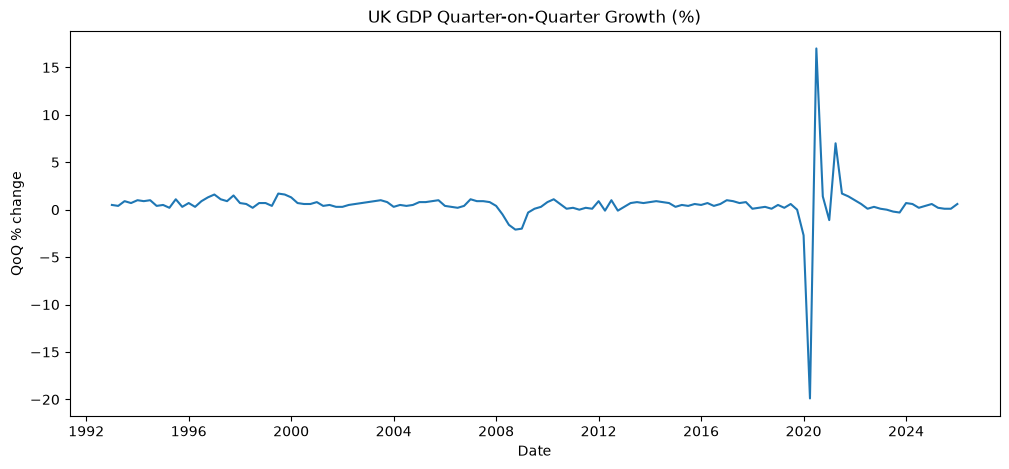

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df['date'], df['value'])
plt.title('UK GDP Quarter-on-Quarter Growth (%)')
plt.xlabel('Date')
plt.ylabel('QoQ % change')
plt.show()

In [6]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['value'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

ADF Statistic: -10.930170097473525
p-value: 9.869007756143519e-20


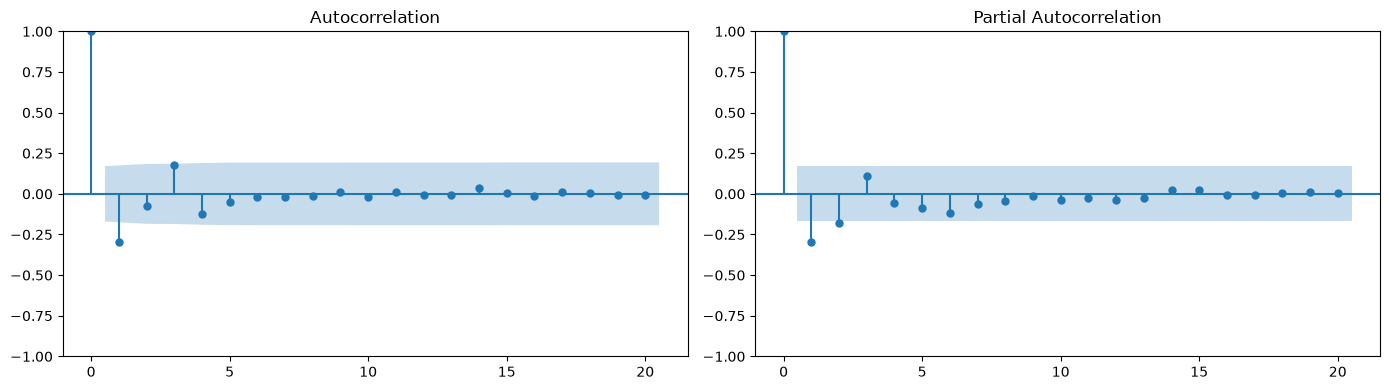

In [7]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(df['value'], lags=20, ax=axes[0])
plot_pacf(df['value'], lags=20, ax=axes[1])
plt.tight_layout()
plt.show()

In [8]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df['value'], order=(1,0,1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  133
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -299.240
Date:                Fri, 17 Jul 2026   AIC                            606.480
Time:                        21:54:06   BIC                            618.042
Sample:                             0   HQIC                           611.179
                                - 133                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5108      0.252      2.023      0.043       0.016       1.006
ar.L1          0.0424      0.171      0.248      0.804      -0.293       0.378
ma.L1         -0.3849      0.167     -2.310      0.0

In [9]:
model_ma = ARIMA(df['value'], order=(0,0,1))
model_ma_fit = model_ma.fit()
print(model_ma_fit.summary())

df_no_covid = df[(df['date'] < '2020-01-01') | (df['date'] > '2021-06-30')].reset_index(drop=True)

model_no_covid = ARIMA(df_no_covid['value'], order=(1,0,1))
model_no_covid_fit = model_no_covid.fit()
print(model_no_covid_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  133
Model:                 ARIMA(0, 0, 1)   Log Likelihood                -299.253
Date:                Fri, 17 Jul 2026   AIC                            604.505
Time:                        21:55:47   BIC                            613.176
Sample:                             0   HQIC                           608.029
                                - 133                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5108      0.253      2.021      0.043       0.015       1.006
ma.L1         -0.3469      0.032    -10.799      0.000      -0.410      -0.284
sigma2         5.2656      0.189     27.920      0.0

In [10]:
df_no_covid = df[(df['date'] < '2020-01-01') | (df['date'] > '2021-06-30')].reset_index(drop=True)

model_no_covid = ARIMA(df_no_covid['value'], order=(1,0,1))
model_no_covid_fit = model_no_covid.fit()
print(model_no_covid_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  127
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 -70.568
Date:                Fri, 17 Jul 2026   AIC                            149.136
Time:                        21:56:36   BIC                            160.513
Sample:                             0   HQIC                           153.759
                                - 127                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5219      0.122      4.268      0.000       0.282       0.762
ar.L1          0.6667      0.088      7.537      0.000       0.493       0.840
ma.L1         -0.0300      0.126     -0.238      0.8